# ch282 — Model Evaluation

*(Continues ch281 — Regression; connects to bias-variance from ch276)*

## 1. Training Error Is Not Generalization Error

Any model can be made to fit its training data arbitrarily well by increasing complexity. The question that matters is: how well does it predict data it has never seen?

**Generalization error** = error on new, unseen data from the same distribution.

All evaluation must be done on data that was not used in training.

---

## 2. Regression Metrics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

def mse(y_true, y_pred):  return np.mean((y_true - y_pred)**2)
def rmse(y_true, y_pred): return np.sqrt(mse(y_true, y_pred))
def mae(y_true, y_pred):  return np.mean(np.abs(y_true - y_pred))
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / ss_tot
def mape(y_true, y_pred): return np.mean(np.abs((y_true - y_pred)/y_true)) * 100

# Generate dataset
n = 300
x = rng.normal(0, 1, n)
y_true = 2 + 3*x + rng.normal(0, 2, n)

# Three predictions: good, biased, noisy
predictions = {
    'Good':   2.1 + 2.9*x + rng.normal(0, 2.1, n),
    'Biased': 5.0 + 2.9*x + rng.normal(0, 2.0, n),  # intercept wrong
    'Noisy':  2.0 + 3.0*x + rng.normal(0, 6.0, n),  # high variance
}

print(f"{'Predictor':<12} {'MSE':>7} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print('-' * 48)
for name, y_pred in predictions.items():
    print(f"{name:<12} {mse(y_true,y_pred):>7.3f} {rmse(y_true,y_pred):>7.3f} "
          f"{mae(y_true,y_pred):>7.3f} {r2(y_true,y_pred):>7.3f}")

Predictor        MSE    RMSE     MAE      R²
------------------------------------------------
Good           9.851   3.139   2.542   0.196
Biased        18.481   4.299   3.569  -0.508
Noisy         43.781   6.617   5.244  -2.573


## 3. Classification Metrics

Classification Metrics:
  accuracy: 0.8900
  precision: 0.8856
  recall: 0.8945
  f1: 0.8900

Confusion matrix:
[[178  23]
 [ 21 178]]


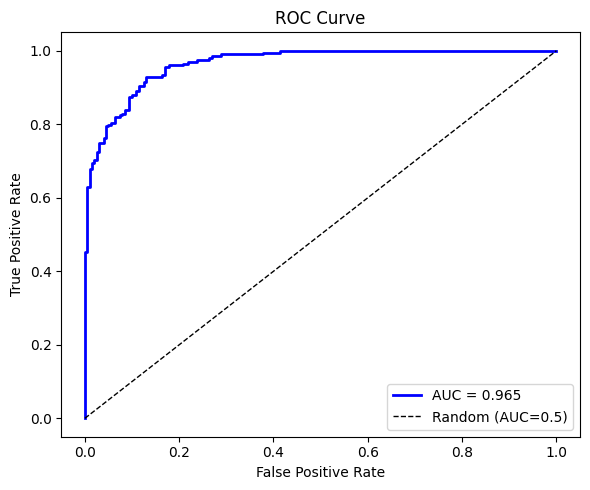

In [3]:
def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """2x2 confusion matrix: [[TN, FP], [FN, TP]]."""
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[tn, fp], [fn, tp]])

def classification_report(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    accuracy  = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': cm}

def roc_auc(y_true: np.ndarray, y_score: np.ndarray) -> tuple[np.ndarray, np.ndarray, float]:
    """Returns (fpr, tpr, auc) for the ROC curve."""
    thresholds = np.sort(np.unique(y_score))[::-1]
    fpr_list, tpr_list = [0], [0]
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        r = classification_report(y_true, y_pred)
        fpr_list.append(1 - r['accuracy'] * len(y_true) / n_neg - r['recall'] * n_pos/n_neg + 1)
        # Use direct formula
        cm = r['cm']
        tpr_list.append(cm[1,1] / n_pos if n_pos > 0 else 0)
        fpr_list[-1] = cm[0,1] / n_neg if n_neg > 0 else 0

    fpr = np.array(fpr_list + [1])
    tpr = np.array(tpr_list + [1])
    auc = np.trapezoid(tpr, fpr)
    return fpr, tpr, auc

# Generate binary classification data
n_cls = 400
x_cls = rng.normal(0, 1, (n_cls, 2))
y_cls = (x_cls[:, 0] + x_cls[:, 1] + rng.normal(0, 0.5, n_cls) > 0).astype(int)

# Simple logistic model: sigmoid of linear combination
def sigmoid(z): return 1 / (1 + np.exp(-z))
z_score = x_cls[:, 0] + x_cls[:, 1] + rng.normal(0, 0.3, n_cls)
y_prob  = sigmoid(z_score)
y_pred_cls = (y_prob > 0.5).astype(int)

rep = classification_report(y_cls, y_pred_cls)
print("Classification Metrics:")
for k, v in rep.items():
    if k != 'cm':
        print(f"  {k}: {v:.4f}")
print(f"\nConfusion matrix:\n{rep['cm']}")

fpr, tpr, auc = roc_auc(y_cls, y_prob)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc:.3f}')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 4. The Train/Test Split

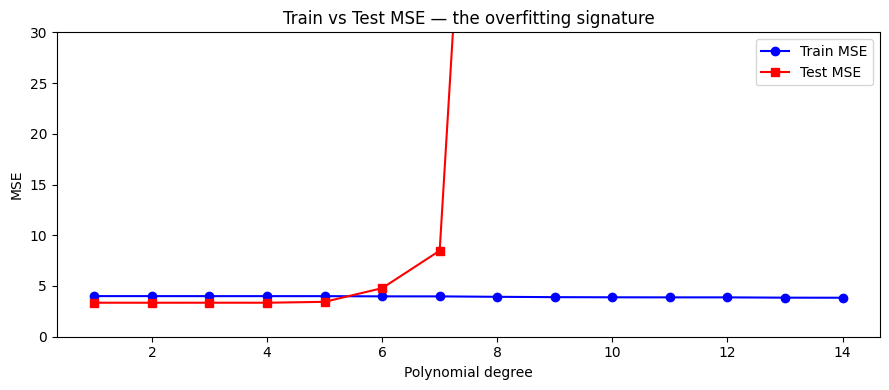

Train MSE monotonically decreases. Test MSE has a minimum.
The gap between them is the overfitting gap.


In [4]:
def train_test_split(
    *arrays, test_size: float = 0.2, rng = None
):
    """Split arrays into random train and test subsets."""
    if rng is None: rng = np.random.default_rng()
    n   = len(arrays[0])
    idx = rng.permutation(n)
    n_test = int(n * test_size)
    test_idx  = idx[:n_test]
    train_idx = idx[n_test:]
    return tuple(a[train_idx] for a in arrays) + tuple(a[test_idx] for a in arrays)

n = 200
xr = rng.normal(0, 1, n)
yr = 2 + 3*xr + rng.normal(0, 2, n)

x_tr, y_tr, x_te, y_te = train_test_split(xr, yr, test_size=0.2, rng=rng)

def fit_and_eval(x_tr, y_tr, x_te, y_te, degree):
    b = np.polyfit(x_tr, y_tr, degree)
    return (
        mse(y_tr, np.polyval(b, x_tr)),
        mse(y_te, np.polyval(b, x_te))
    )

degrees = range(1, 15)
train_mses = []
test_mses  = []

for d in degrees:
    tr_mse, te_mse = fit_and_eval(x_tr, y_tr, x_te, y_te, d)
    train_mses.append(tr_mse)
    test_mses.append(te_mse)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(degrees, train_mses, 'o-', color='blue',  label='Train MSE')
ax.plot(degrees, test_mses,  's-', color='red',   label='Test MSE')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel('MSE')
ax.set_ylim(0, 30)
ax.set_title('Train vs Test MSE — the overfitting signature')
ax.legend()
plt.tight_layout()
plt.show()

print("Train MSE monotonically decreases. Test MSE has a minimum.")
print("The gap between them is the overfitting gap.")

## 5. What Comes Next

The train/test gap just visualized is overfitting. **ch283 — Overfitting** explains it mechanically via the bias-variance tradeoff and presents regularization as a remedy. **ch284 — Cross Validation** replaces the single random train/test split with a procedure that gives a more stable estimate of generalization error.